In [11]:
# el "robot" ahora esta en un ambiente 3d se puede mover de izquierda aderecha y tambien apra arriba o abajo
# tipo simular que puede volar o algo asi, los obstaculos tambien puedes estar en cualquer parte del plano como
# flotando seguiran siendo figuras en este caso, las graficas en este caso tardan mucho en cargar porque al ser 
#demasiados puntos tardan en cargar pero si cargan, tambien para visualizar el camino final se puede solo grafucar esa
# porque hay varios casoa que no se puede visualizar la meta o inicio en la grafica porque rrrecorre mcuhos caminos y nodos
# lo que impide visualizar eso y hasta los obstaculos :)

import matplotlib.pyplot as plt
import numpy as np

In [12]:
# aqui solo agregue z para pasarlo a 3d
class Obstaculo():# funcion deS obstaculo tipo cuadrado
    def __init__(self, limxMax, limxMin ,limyMax, limyMin, limzMax, limzMin):
        self.limites = [limxMax, limxMin ,limyMax, limyMin, limzMax, limzMin]
 
    def in_collision(self, x, y, z): # Detecta si el punto esta dentro del rectangulo
        if self.limites[0]>= x >= self.limites[1] and self.limites[2]>= y >= self.limites[3]  and self.limites[4] >= z >= self.limites[5]:
            return True
        return False
 
class Obstaculo_circulo():# funcion de obstaculo tipo circulo
    def __init__(self, centerx, centery,centerz, radius):
        self.center = [centerx, centery, centerz]
        self.radius = radius
    
    def in_collision(self, x, y, z): # vee si el punto est dentro del crculo
        d = np.sqrt((x-self.center[0])**2 + (y-self.center[1])**2 + (z - self.center[2])**2)
        if d <= self.radius:
            return True
        return False
print("hola")

hola


In [13]:
obst1 = Obstaculo(5, -5, 15, 8, 2,6) #creamos un obstaculo
 
#obst1.in_collision(2,10)
print(obst1.in_collision(0,0,0)) #no esta dentro del obstaculo
 
#obstCircle = Obstaculo_circulo(2,2,5)#centro en 2,2 y con un radio de 5
#obstCircle.in_collision(8,5)
print("hola")

False
hola


In [14]:
visitados=[]
por_visitar=[]
limx = [-20,20]#limites del plano cartesiano
limy = [-20,20]
limz = [-20,20] #z
 
class Nodo():
    
    def __init__(self, pos=[0,0,0], papa=None):# pos=posicion del robot, apapa= null
        self.pos = pos
        self.hijos=[]#poisibles movimientos
        self.papa = papa
        self.h = 0 #distancia de la meta (heuristica)
        if papa: # num pasos desde el inicio
            self.costo= papa.costo +1
        else: 
            self.costo = 0
        #self.costo = costo + 1
        
    def genera_hijos(self, obstaculos):
        
        pos_arriba = [self.pos[0], self.pos[1]+1, self.pos[2]] #movemos y+1
        
        pos_der = [self.pos[0]+1, self.pos[1], self.pos[2]] #movemos x+1
        
        pos_abajo = [self.pos[0], self.pos[1]-1, self.pos[2]] #movemos y-1
        
        pos_izq = [self.pos[0]-1, self.pos[1], self.pos[2]] #movemos x-1
        
        pos_arriba_z = [self.pos[0], self.pos[1], self.pos[2]+1] #movemos z+1
        
        pos_abajo_z = [self.pos[0], self.pos[1], self.pos[2]-1] #movemos z-1
        
        if pos_arriba[1] < limy[1]:# pos_arriba[y] debe ser menor que límite superior y
            se_puede = True
            for ob in obstaculos:
                if (ob.in_collision(pos_arriba[0], pos_arriba[1], pos_arriba[2])):
                    se_puede = False
                    break
            if se_puede:
                self.hijos.append(Nodo(pos_arriba,self))
        if pos_der[0] < limx[1]:# pos_der[x] debe ser menor que límite superior x
            se_puede = True
            for ob in obstaculos:
                if (ob.in_collision(pos_der[0], pos_der[1], pos_der[2])):
                    se_puede = False
                    break
            if se_puede:
                self.hijos.append(Nodo(pos_der,self))
        if limy[0] < pos_abajo[1]: #pos_abajo[y] debe ser mayor que límite inferior y
            se_puede = True
            for ob in obstaculos:
                if (ob.in_collision(pos_abajo[0], pos_abajo[1], pos_abajo[2])):
                    se_puede = False
                    break
            if se_puede:
                self.hijos.append(Nodo(pos_abajo,self))
        if limx[0]< pos_izq[0]: #pos_izq[x] debe ser mayor que límite inferior x   
            se_puede = True
            for ob in obstaculos:
                if (ob.in_collision(pos_izq[0], pos_izq[1], pos_izq[2])):
                    se_puede = False
                    break
            if se_puede:
                self.hijos.append(Nodo(pos_izq,self))
                
        if pos_arriba_z[2] < limz[1]: # pos_arriba_z[z] debe ser menor que límite superior x
            se_puede = True
            for ob in obstaculos:
                if (ob.in_collision(pos_arriba_z[0], pos_arriba_z[1], pos_arriba_z[2])):
                    se_puede = False
                    break
            if se_puede:
                self.hijos.append(Nodo(pos_arriba_z,self))
                
        if limz[0]<pos_abajo_z[2]:#pos_abajo_z[] debe ser mayor que límite inferior x   
            se_puede = True
            for ob in obstaculos:
                if (ob.in_collision(pos_abajo_z[0], pos_abajo_z[1], pos_abajo_z[2])):
                    se_puede = False
                    break
            if se_puede:
                self.hijos.append(Nodo(pos_abajo_z,self))
# (profundidad) a 3D
# aqui me mandaba un problema de recursion(porque pyhton tiene lim) si lo dejaba con la misma estructura la bpp so...
#entonces usando una pila como se van amontonando es como recursion
    def bpp(self, goalpos, obstaculos): #búsqueda primero en profundidad(el, meta, arreglo/lista de obstaculos )
        visitados_bpp = set() # porque pueden ser muichos entonces utilizo set(mas rapido)
        pila = [self]
        while pila:
            nodo_actual = pila.pop()
            pos_tupla = tuple(nodo_actual.pos)
            if pos_tupla in visitados_bpp:
                continue
            if nodo_actual.pos == goalpos:
                # tenemos que hace rel camino manualmente
                trayectoria = [nodo_actual]
                padre = nodo_actual.papa
                while padre:
                    trayectoria.append(padre)
                    padre = padre.papa
                return trayectoria
            
            nodo_actual.genera_hijos(obstaculos)
            visitados_bpp.add(pos_tupla)
            #seguimos recorriendo
            for hijo in nodo_actual.hijos:
                if tuple(hijo.pos) not in visitados_bpp:
                    pila.append(hijo)
        return None
 #en bpa solo modifque la lista de visitados porque cuando queria graficar en 3d tardaba demasiado tiempo y ahi se quedaba el programa
 #entonces investigue (porque si queremos algo pyhton ya lo creo) y utilize la set para ser mas rapido a la hora de buscar
    def bpa(self, goalpos, obstaculos):
        visitados_bpa = set() # para buscar rapido y no mande error
        if self.pos == goalpos:
            return [self] # si lo encontramos entonces vamos a regresar una lista con el último      
        self.genera_hijos(obstaculos)
        visitados_bpa.add(tuple(self.pos)) # pasamos a tupla porque set no acepta listas
        por_visitar = self.hijos.copy()
        while por_visitar != []:
            hijo = por_visitar.pop(0)# primer nodo de la cola
            if tuple(hijo.pos) not in visitados_bpa:                
                if hijo.pos == goalpos:
                    #return [self]
                    trayectoria = [hijo]
                    padre = hijo.papa
                    while padre:
                        trayectoria.append(padre)
                        padre = padre.papa
                    return trayectoria
                hijo.genera_hijos(obstaculos)
                por_visitar = por_visitar + hijo.hijos.copy()
                visitados_bpa.add(tuple(hijo.pos))
        return []
 
    def heuristica(self, goalpos): # esta es la función h(n) 
        self.h = np.sqrt((goalpos[0] - self.pos[0])**2 +(goalpos[1] - self.pos[1])**2 +(goalpos[2] - self.pos[2])**2
        )
        return self.h # vee si este nodo esta cerca o lejos del objetivo
        
    def f_n(self, goalpos):
        self.f = self.costo + self.heuristica(goalpos) # lo que ya camino - > lo que falta
        return self.f 
        
    def a_estrella(self, goalpos, obstaculos):
        vistados = []
        por_visitar = [self]
        while por_visitar != []: # sigue mientras haya nodos
            hijo = por_visitar.pop(0)
            if not hijo in visitados:                
                if hijo.pos == goalpos:
                    #return [self]
                    trayectoria = [hijo]
                    padre = hijo.papa
                    while padre:
                        trayectoria.append(padre)
                        padre = padre.papa
                    return trayectoria
                hijo.genera_hijos(obstaculos)
                for nieto in hijo.hijos:
                    nieto.f_n(goalpos)  # Calcula f a cada hijo
                por_visitar = por_visitar + hijo.hijos.copy()
                por_visitar = sorted(por_visitar, key = lambda node:node.f) # ordena por f menor para elegir el mejor camino
                visitados.append(hijo) 
        return []  
    
    def greedy(self, goalpos, obstaculos): # siempre elige el nodo mas cercano a la meta con forme a la heuristica
        vistados = []
        por_visitar = [self]
        while por_visitar != []:
            hijo = por_visitar.pop(0)
            if not hijo in visitados:                
                if hijo.pos == goalpos:
                    #return [self]
                    trayectoria = [hijo]
                    padre = hijo.papa
                    while padre:
                        trayectoria.append(padre)
                        padre = padre.papa
                    return trayectoria
                hijo.genera_hijos(obstaculos)
                for nieto in hijo.hijos:
                    nieto.heuristica(goalpos)
                por_visitar = por_visitar + hijo.hijos.copy()
                por_visitar.sort()
                visitados.append(hijo) 
        return []  
    #TAMBIEN SE PASA A PILA EN VEZ DE RECURSION
    def to_list(self): # convierte todo el arbol en una lista de nodos
        list_of_nodes = []
        pila = [self]
        while pila:
            nodo = pila.pop()
            list_of_nodes.append(nodo)
            for h in nodo.hijos:
                pila.append(h)
        return list_of_nodes
    
    def __repr__(self): # como imprime nodos: x:2,y:5
        return str(f"x:{self.pos[0]},y:{self.pos[1]},z:{self.pos[2]}")
 
    def __eq__(self, elotro): # Compara si dos nodos son iguales (pense que decia elote)
        if self is not None and elotro is not None:
            if self.pos == elotro.pos:
                return True
            else:
                return False
                
    #nodo1 < nodo2
    def __lt__(self, elotro): # Define como comparar nodos con <
        return self.h < elotro.h 

print("hola")

hola


In [15]:
print("hola")
class Robot():
    def __init__(self, dof, numb=1):
        self.dof = dof # grados de libertad
        self.model = None
        self.num_bodies = numb
        self.global_position = [0,0,0]
        self.trajectory = []
        self.espacio_estados = []
        self.obstaculos = []
        
    def add_obstacle(self, limxMax, limxMin ,limyMax, limyMin, limzMax, limzMin): # añadimos obstauclos o limites
        self.obstaculos.append(Obstaculo(limxMax, limxMin ,limyMax, limyMin, limzMax, limzMin))
        
    def add_circle_obstacle(self, centerx, centery,centerz, rad):# crea obstaculos circular
        self.obstaculos.append(Obstaculo_circulo(centerx, centery, centerz, rad))

    def get_obst_circle(self):# veer los obstaculos del robot
        for obs in self.obstaculos:
            if isinstance(obs, Obstaculo_circulo): #¡circulo o no?
                return plt.Circle(obs.center, obs.radius, fill=False) # crea un objeto graico de circulo
                
    def draw_obstacles(self, canvas): # Convierte obstculos del robot en figuras visibles en el plano
        for obs in self.obstaculos:
            if isinstance(obs, Obstaculo_circulo):# dibujar circulo
                u = np.linspace(0, 2*np.pi, 100)
                x = obs.center[0] + obs.radius * np.cos(u)
                y = obs.center[1] + obs.radius * np.sin(u)
                z = np.full_like(x, obs.center[2])
                canvas.plot(x, y, z, color='green')
            else: # dibujar cuadrado
                #print("cuadrado")
                canvas.plot(
                    [obs.limites[1], obs.limites[0], obs.limites[0], obs.limites[1], obs.limites[1]],
                    [obs.limites[3], obs.limites[3], obs.limites[2], obs.limites[2], obs.limites[3]],
                    [obs.limites[5], obs.limites[4], obs.limites[4], obs.limites[5], obs.limites[5]],
                    color = 'red'
                )
                
    def draw_generated_nodes(self, canvas):# es todo el caMino que exploro el robot( estrella azul)
        if self.raiz != None:
            nodos = self.raiz.to_list()
            xs, ys, zs = [], [], []
            for nodo in nodos:
                xs.append(nodo.pos[0])
                ys.append(nodo.pos[1])
                zs.append(nodo.pos[2])
            canvas.scatter(xs, ys, zs, marker='*', color='blue')
        else:
            print("Calcular la Trayectoria primero")
    
    def draw_trajectory(self, canvas): # solo el camino final (amarillo)
        lasx = []
        lasy = []
        lasz = []
        for estado in self.trajectory:
            x,y,z = estado.pos    
            lasx.append(x)
            lasy.append(y)
            lasz.append(z)
        if lasx!=[]:
            canvas.scatter(lasx[0], lasy[0], lasz[0])
            canvas.scatter(lasx[1:], lasy[1:], lasz[1:])
        canvas.scatter(self.raiz.pos[0], self.raiz.pos[1], self.raiz.pos[2], marker="^", color="yellow")
    
    def plot_all(self): # crea el plano
        fig = plt.figure()# subplots no funciona con 3D, entonces figure
        ax = fig.add_subplot(111, projection='3d')
        ax.set_xlim(-20,20)
        ax.set_ylim(-20,20)
        ax.set_zlim(-20,20)
        self.draw_generated_nodes(ax) # todos los nodos explotados (estrella)
        
        ax.plot( # dibuja borde del mundo del robor o limites color morado
            [limx[0], limx[1], limx[1], limx[0], limx[0]],
            [limy[1], limy[1], limy[0], limy[0], limy[1]],
            [limz[0], limz[0], limz[0], limz[0], limz[0]],
            color = 'purple'
        )
        
        self.draw_trajectory(ax)
        self.draw_obstacles(ax)      
    
    def move(self, pos): # mueve el robot a la dicha posision
        #self.trajectory.append(self.global_position.copy()) # o también self.global_position[:]
        for x in range(pos[0]+1):
            self.global_position[0] = x 
            self.trajectory.append(self.global_position.copy())
        for y in range(pos[1]+1):
            self.global_position[1] = y
            self.trajectory.append(self.global_position.copy())
        for z in range(pos[2]+1):
            self.global_position[2] = z
            self.trajectory.append(self.global_position.copy())

    def busca_camino_goal(self, goalpos, search_mode="bpp"): #encuentra un camino hasta la meta
        self.raiz = Nodo(self.global_position) #  usa bpp para encontrar el camino
        if search_mode == "bpp":# aqui se esocge como buscar el camino
            self.trajectory = self.raiz.bpp(goalpos, self.obstaculos)
        elif search_mode == "bpa":
            self.trajectory = self.raiz.bpa(goalpos, self.obstaculos)
        elif search_mode == "greedy":
            self.trajectory = self.raiz.greedy(goalpos, self.obstaculos)
        elif search_mode == "A*":
            self.trajectory = self.raiz.a_estrella(goalpos, self.obstaculos)
        return self.trajectory
   # otra forma de dibujar como matriz(ya no estrellas ni eso)         
    def get_occupancy_grid(self): # convierte el mundo del robot en una rejilla
        grid = {} #  representacion tipo MATRIZ del mundo, 1= opbstaculo, 0 = libre
        grid2 = np.zeros((40,40,40)) # cada punto indica si hay obstculo o no
        for x in range(limx[0],limx[1]):
            for y in range(limy[0],limy[1]):
                for z in range(limz[0],limz[1]):
                    grid[str(x)+","+str(y)+","+str(z)] = 0
                    
                    for obs in self.obstaculos:
                        if obs.in_collision(x,y,z):
                            #print(x,y,z) lo comente porque serian demasiados
                            grid[str(x)+","+str(y)+","+str(z)] = 1   
                            grid2[x+20,y+20,z+20] = 1
        return grid, grid2

    def draw_occupancy_grid(self): # dibuja en la grafica los 1 o 0 de obstaculos
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.set_xlim(-20,20)
        ax.set_ylim(-20,20)
        ax.set_zlim(-20,20)
        ax.plot(
            [limx[0], limx[1], limx[1], limx[0], limx[0]],
            [limy[1], limy[1], limy[0], limy[0], limy[1]],
            [limz[0], limz[0], limz[0], limz[0], limz[0]],
            color = 'purple'
        )
        for x in range(limx[0],limx[1]):
            for y in range(limx[0], limy[1]):
                for z in range(limz[0], limz[1]):
                    if (grid[str(x)+","+str(y)+","+str(z)]):
                        ax.scatter(x=x,y=y,z=z, c="black")
        
    def next_positions(self): # a donde me puedo mover desde posicion actual
        mi_pos = Nodo(self.global_position)
        mi_pos.genera_hijos()
        tray= [mi_pos.pos,mi_pos.hijos[0].pos,mi_pos.hijos[1].pos,mi_pos.hijos[2].pos,mi_pos.hijos[3].pos]
        return tray
            
robot1 = Robot(6)
robot2 = Robot(3,3)

hola


In [16]:
print("hola")
visitados=[]
robot1 = Robot(6)
#print(robot1.dof)
#tray = robot1.next_positions()
robot1.add_obstacle(5, -5, 15, 8, 3, 1)       # ahora con limzMax y limzMin
robot1.add_circle_obstacle(10, 0, 5, 3)            # centerz=0 por default
tray = robot1.busca_camino_goal([5,5,3])   # meta con z
#print(tray)
lasx = []
lasy = []
lasz = []
for estado in tray:
    x, y, z = estado.pos                        # ahora desempacamos 3 valores
    lasx.append(x)
    lasy.append(y)
    lasz.append(z)

hola


hola


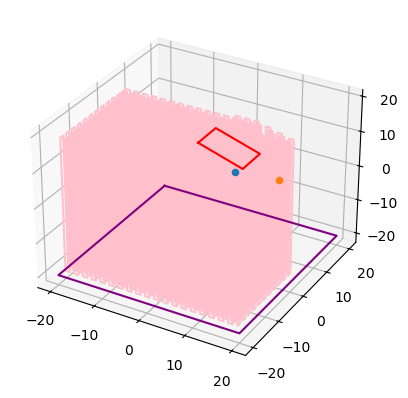

In [17]:
print("hola")
from mpl_toolkits.mplot3d import Axes3D
#graficar en 3d se usa ax en vez de plot y solo se añade z
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(lasx[0], lasy[0], lasz[0])  # inicio
#ax.scatter(lasx[1:], lasy[1:], lasz[1:])       # trayectoria}
ax.plot(lasx, lasy, lasz, color='pink')  # linea
#ax.scatter(x=12, y=10, z=0)                  # meta
ax.scatter(12,10,0)  
ax.plot(
    [limx[0], limx[1], limx[1], limx[0], limx[0]],
    [limy[1], limy[1], limy[0], limy[0], limy[1]],
    [limz[0], limz[0], limz[0], limz[0], limz[0]],
    color='purple'
)

ax.plot(
    [obst1.limites[1], obst1.limites[0], obst1.limites[0], obst1.limites[1], obst1.limites[1]],
    [obst1.limites[3], obst1.limites[3], obst1.limites[2], obst1.limites[2], obst1.limites[3]],
    [obst1.limites[5], obst1.limites[4], obst1.limites[4], obst1.limites[5], obst1.limites[5]],
    color='red'
)

plt.show()

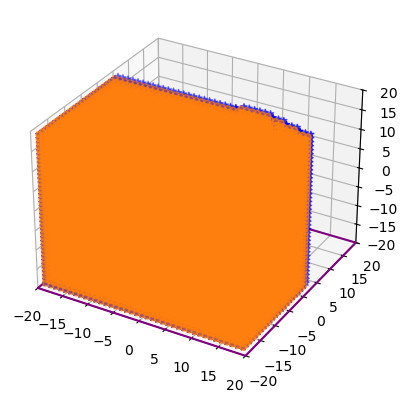

In [19]:
#obstCircle = Obstaculo_circulo(10,0,5)#centro en 2,2 y con un radio de 5


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#elcirculo = robot1.get_obst_circle()
#elciculo = plt.Circle(obstCircle.center, obstCircle.radius, fill=False)
#elciculo = plt.Circle((.2,.2), .3)

ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_zlim(-20,20)
robot1.draw_generated_nodes(ax)

ax.plot(
    [limx[0], limx[1], limx[1], limx[0], limx[0]],
    [limy[1], limy[1], limy[0], limy[0], limy[1]],
    [limz[0], limz[0], limz[0], limz[0], limz[0]],
    color = 'purple'
)
#ax.scatter(x=obst1.limites[:2], y=obst1.limites[2:])
#ax.plot(
#    [obst1.limites[1], obst1.limites[0], obst1.limites[0], obst1.limites[1], obst1.limites[1]],
#    [obst1.limites[3], obst1.limites[3], obst1.limites[2], obst1.limites[2], obst1.limites[3]],
#    color = 'red'
#)

#ax.set_aspect(1)
robot1.draw_trajectory(ax)
robot1.draw_obstacles(ax)
plt.show()
#ax.add_artist(elcirculo)

In [20]:
visitados =[]
por_visitar=[]
tray = robot1.busca_camino_goal([12,10, 0], "bpa")
print("hola")

hola


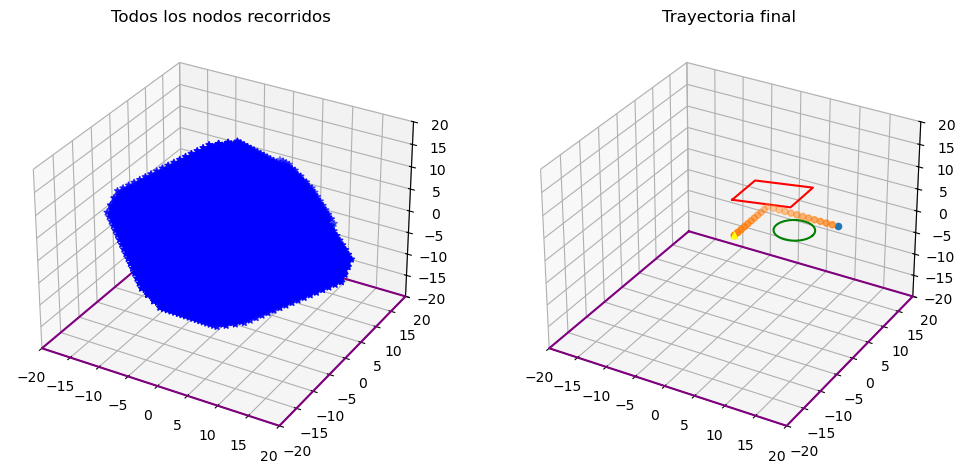

In [210]:
fig = plt.figure(figsize=(12,6))

# solo trayectoria directa y corta a la ma
ax = fig.add_subplot(121, projection='3d')
ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_zlim(-20,20)
robot1.draw_generated_nodes(ax)
ax.set_title("Todos los nodos recorridos")
ax.plot(
    [limx[0], limx[1], limx[1], limx[0], limx[0]],
    [limy[1], limy[1], limy[0], limy[0], limy[1]],
    [limz[0], limz[0], limz[0], limz[0], limz[0]],
    color='purple'
)
robot1.draw_trajectory(ax)
robot1.draw_obstacles(ax)

# subplot derecho - con nodos explorados
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_xlim(-20,20)
ax2.set_ylim(-20,20)
ax2.set_zlim(-20,20)
ax2.set_title("Trayectoria final")
ax2.plot(
    [limx[0], limx[1], limx[1], limx[0], limx[0]],
    [limy[1], limy[1], limy[0], limy[0], limy[1]],
    [limz[0], limz[0], limz[0], limz[0], limz[0]],
    color='purple'
)
robot1.draw_trajectory(ax2)
robot1.draw_obstacles(ax2)

plt.show()

In [211]:
robot1.add_obstacle(5, -5, 15, 8,3,1)
robot1.add_circle_obstacle(10,0,5, 3)
tray = robot1.busca_camino_goal([12,10,0], "greedy")
print("hola")

hola


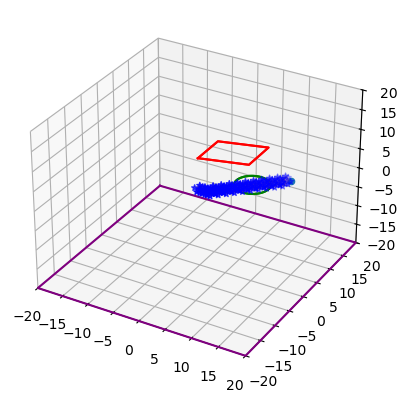

In [214]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_zlim(-20,20)
robot1.draw_generated_nodes(ax)
ax.plot(
    [limx[0], limx[1], limx[1], limx[0], limx[0]],
    [limy[1], limy[1], limy[0], limy[0], limy[1]],
    [limz[0], limz[0], limz[0], limz[0], limz[0]],
    color='purple'
)
robot1.draw_trajectory(ax)
robot1.draw_obstacles(ax)
plt.show()

In [230]:
visitados =[]
por_visitar=[]
tray = robot1.busca_camino_goal([12,10, 3], "A*")

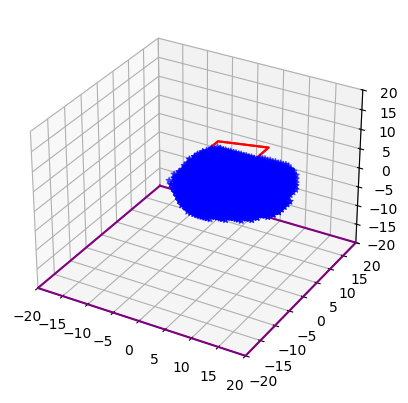

In [231]:
robot1.plot_all()

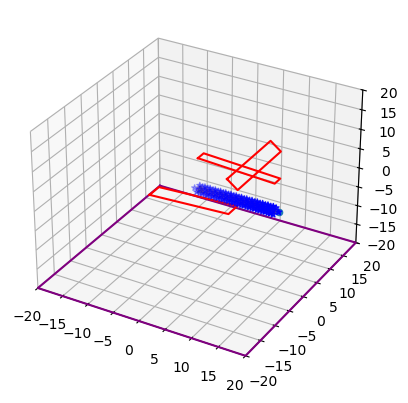

In [232]:
visitados = []
por_visitar = []
robot2 = Robot(6)
robot2.add_obstacle(10, -5, 10, 8, 0 , 1)
robot2.add_obstacle(10, -5, -5, -8, 3, 2)
robot2.add_obstacle(10, 8, 10, -5, 7, 9)
#robot2.add_circle_obstacle(10,0,5)
tray = robot2.busca_camino_goal([15,0, 0], "A*")
robot2.plot_all()

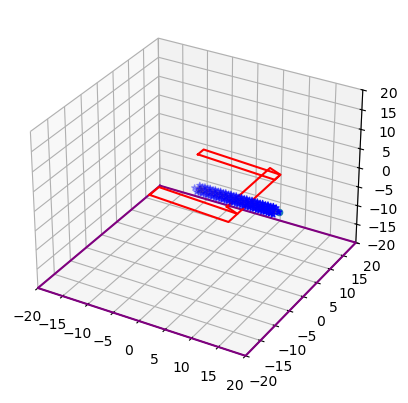

In [233]:
visitados = []
por_visitar = []
robot2 = Robot(6)
robot2.add_obstacle(10, -5, 10, 8, 1,2)
robot2.add_obstacle(10, -5, -5, -8,1,2)
robot2.add_obstacle(10, 8, 10, -5,1,2)
#robot2.add_circle_obstacle(10,0,5)
tray = robot2.busca_camino_goal([15,0,0], "greedy")
robot2.plot_all()

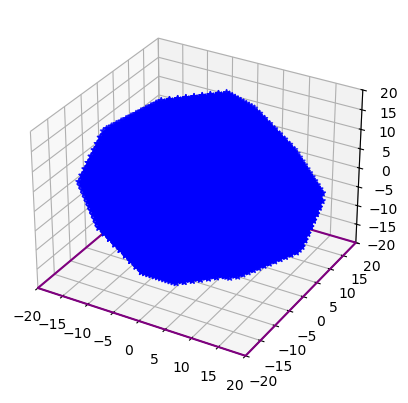

In [238]:
visitados = []
por_visitar = []
robot2 = Robot(6)
robot2.add_obstacle(10, -5, 10, 8,0,0)
robot2.add_obstacle(10, -5, -5, -8,9,0)
robot2.add_obstacle(10, 8, 10, -5,0,0)
#robot2.add_circle_obstacle(10,0,5)
tray = robot2.busca_camino_goal([15,0,12], "bpa")

robot2.plot_all()

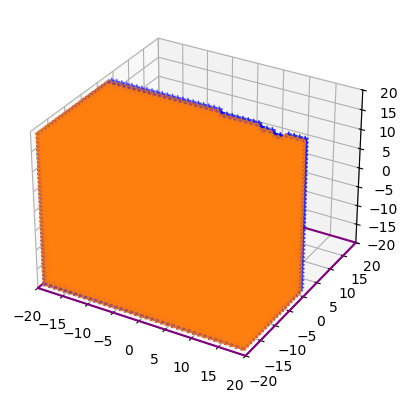

In [239]:
visitados = []
por_visitar = []
robot2 = Robot(6)
robot2.add_obstacle(10, -5, 10, 8, 4,6)
robot2.add_obstacle(10, -5, -5, -8,3,5)
robot2.add_obstacle(10, 8, 10, -5,-1,-1)
#robot2.add_circle_obstacle(10,0,5)
tray = robot2.busca_camino_goal([15,0,-1], "bpp")
robot2.plot_all()

hay que traducir nuestro entorno en un grid de ocupación

In [119]:
grid, grid2 = robot1.get_occupancy_grid()
#grid

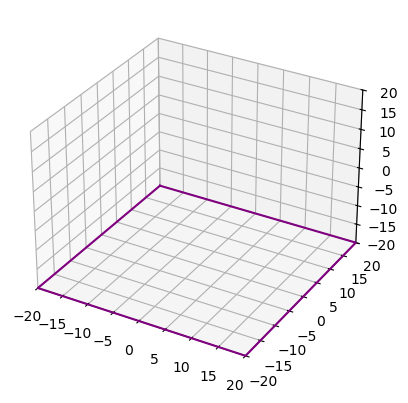

In [123]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-20,20)
ax.set_ylim(-20,20)
ax.set_zlim(-20,20)
ax.plot(
    [limx[0], limx[1], limx[1], limx[0], limx[0]],
    [limy[1], limy[1], limy[0], limy[0], limy[1]],
    [limz[0], limz[0], limz[0], limz[0], limz[0]],
    color='purple'
)
for x in range(limx[0],limx[1]):
    for y in range(limx[0], limy[1]):
        for z in range(limz[0], limz[1]):
            if (grid[str(x)+","+str(y)+","+str(z)]):
                ax.scatter(x, y, z, c="black")
robot1.draw_obstacles(ax)
plt.show()

In [125]:
grid["-5,12,0"]

0

In [126]:
grid["10,0,3"]

0

In [127]:
grid2 = np.zeros((40,40,40))

In [128]:
grid2[grid2==1]

array([], dtype=float64)

In [129]:
X.shape

NameError: name 'X' is not defined

In [133]:
puntos = np.random.randint(-20, 20,(1000,2,3))
#np.random.uniform(-20, 20, (n_samples, 20, 20))

In [134]:
puntos

array([[[ 17, -10, -16],
        [ -4, -14,   7]],

       [[  5,  -1,  -2],
        [  9,  -4,  -8]],

       [[  5,  19,  12],
        [-20, -13,  -5]],

       ...,

       [[  2, -12,   0],
        [  1, -11, -10]],

       [[ 17,  -6,  -8],
        [  8,  16, -11]],

       [[ 12,   4,  -1],
        [-14, -12,   2]]], shape=(1000, 2, 3), dtype=int32)

In [136]:
list_maps=[]
for punto1, punto2 in puntos:
    gridtmp = grid2.copy()
    gridtmp[punto1[0], punto1[1], punto1[2]] = 2
    gridtmp[punto2[0], punto2[1], punto2[2]] = 3
    
    list_maps.append(gridtmp)
list_maps  

gridplot=list_maps[0]
xs, ys, zs = np.where(gridplot == 2)
ax.scatter(xs-20, ys-20, zs-20, c='blue')
xs, ys, zs = np.where(gridplot == 3)
ax.scatter(xs-20, ys-20, zs-20, c='red')
print(gridplot)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


In [137]:
grid2[:,0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(40, 40))

In [140]:
x, y,z = np.indices(grid2.shape)
values = grid2.flatten()

In [141]:
x

array([[[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1],
        ...,
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1]],

       [[ 2,  2,  2, ...,  2,  2,  2],
        [ 2,  2,  2, ...,  2,  2,  2],
        [ 2,  2,  2, ...,  2,  2,  2],
        ...,
        [ 2,  2,  2, ...,  2,  2,  2],
        [ 2,  2,  2, ...,  2,  2,  2],
        [ 2,  2,  2, ...,  2,  2,  2]],

       ...,

       [[37, 37, 37, ..., 37, 37, 37],
        [37, 37, 37, ..., 37, 37, 37],
        [37, 37, 37, ..., 37, 37, 37],
        ...,
        [37, 37, 37, ..., 37, 37, 37],
        [37, 37, 37, ..., 37, 37, 37],
        [37, 37, 37, ..., 37, 37

In [142]:
y

array([[[ 0,  0,  0, ...,  0,  0,  0],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 2,  2,  2, ...,  2,  2,  2],
        ...,
        [37, 37, 37, ..., 37, 37, 37],
        [38, 38, 38, ..., 38, 38, 38],
        [39, 39, 39, ..., 39, 39, 39]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 2,  2,  2, ...,  2,  2,  2],
        ...,
        [37, 37, 37, ..., 37, 37, 37],
        [38, 38, 38, ..., 38, 38, 38],
        [39, 39, 39, ..., 39, 39, 39]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 2,  2,  2, ...,  2,  2,  2],
        ...,
        [37, 37, 37, ..., 37, 37, 37],
        [38, 38, 38, ..., 38, 38, 38],
        [39, 39, 39, ..., 39, 39, 39]],

       ...,

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 2,  2,  2, ...,  2,  2,  2],
        ...,
        [37, 37, 37, ..., 37, 37, 37],
        [38, 38, 38, ..., 38, 38, 38],
        [39, 39, 39, ..., 39, 39

In [143]:
values

array([0., 0., 0., ..., 0., 0., 0.], shape=(64000,))

In [ ]:
# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
sc = plt.scatter(x.flatten(), y.flatten(), c=values, cmap='viridis', s=100)

# Añadir barra de colores
plt.colorbar(sc, label='Valor de la matriz de adyacencia')

# Etiquetas y título
plt.xlabel('Nodo i')
plt.ylabel('Nodo j')
plt.title('Gráfico de dispersión de la matriz de adyacencia')

# Mostrar el gráfico
plt.show()

In [ ]:
n_samples = 1000
puntos = np.random.randint(-20, 20,(n_samples,2,2))

list_maps=[]
list_maps_out = []
for punto1, punto2 in puntos:
    gridtmp = grid2.copy()
    gridout = grid2.copy()
    gridtmp[punto1[0]+20, punto1[1]+20] = 2
    gridtmp[punto2[0]+20,punto2[1]+20] = 3
    visitados =[]
    por_visitar=[]
    rx = robot1
    rx.global_position = punto1.tolist()
    tray = rx.busca_camino_goal(punto2.tolist(), "A*")
    for nodo in tray:
        ex,ey = nodo.pos
        gridout[ex+20,ey+20] = 4
    list_maps.append(gridtmp)
    list_maps_out.append(gridout)

#x, y = np.indices(grid2.shape)
#values = grid2.flatten()

In [ ]:
plt.figure(figsize=(8, 6))

mapa=list_maps[-1]
#for mapa in list_maps:
x, y = np.indices(mapa.shape)
values = mapa.flatten()
sc = plt.scatter(x.flatten(), y.flatten(), c=values, cmap='viridis', s=50)

# Añadir barra de colores
plt.colorbar(sc, label='Valor de la matriz de adyacencia')

# Etiquetas y título
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Gráfico de dispersión de la matriz de adyacencia')

# Mostrar el gráfico
plt.show()

In [ ]:
robot1.plot_all()

In [ ]:
X = np.array(list_maps[:700])
y = np.array(list_maps_out[:700])
y.shape
xtest = np.array(list_maps[700:])
ytest = np.array(list_maps_out[700:])

In [ ]:
ytest.shape

In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor, MLPClassifier

# Generar datos de ejemplo
# Supongamos que tenemos 1000 ejemplos de matrices 40x40 de entrada y salida

#X = np.random.rand(n_samples, 20, 20)
#y = np.random.rand(n_samples, 20, 20)




In [ ]:
# Redimensionar los datos para que puedan ser procesados por MLPRegressor
# MLPRegressor espera datos en 2D, así que convertimos las matrices 40x40 a vectores de longitud 400
X = X.reshape(700, 1600)
y = y.reshape(700, 1600)

In [ ]:
X.shape

In [ ]:
xtest = xtest.reshape(300,1600)
#ytest = ytest.reshape(300,1600)

In [ ]:
# Crear el modelo
# Puedes ajustar los parámetros del MLPRegressor según tus necesidades
model = MLPRegressor(hidden_layer_sizes=(1024, 1024), activation='relu', max_iter=100000)

# Entrenar el modelo
model.fit(X, y)

# Predecir nuevas matrices
# Generar un nuevo conjunto de matrices de prueba
#X_test = np.random.rand(10, 20, 20)  # Por ejemplo, 10 nuevas matrices
#X_test = X_test.reshape(10, 400)

# Hacer predicciones
y_pred = model.predict(xtest)

# Volver a convertir las predicciones a la forma original de 20x20
y_pred = y_pred.reshape(300, 40, 40)

#print("Predicciones de prueba (matrices de 20x20):")
#print(y_pred)


In [ ]:
#y_pred = y_pred.reshape(300, 40, 40)

In [ ]:
def plot_grid(grid):
    plt.figure(figsize=(8, 6))
    
    #mapa=list_maps[-1]
    #for mapa in list_maps:
    x, y = np.indices(grid.shape)
    values = grid.flatten()
    sc = plt.scatter(x.flatten(), y.flatten(), c=values, cmap='viridis', s=50)
    
    # Añadir barra de colores
    plt.colorbar(sc, label='correspondencia')
    
    # Etiquetas y título
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Mapa')
    
    # Mostrar el gráfico
    plt.show()

In [ ]:
plot_grid(y_pred[0])

In [ ]:
ytest = ytest.reshape(300,40,40)
plot_grid(ytest[0])

In [ ]:
n_samples = 1000
puntos = np.random.randint(-20, 20,(n_samples,2,2))

list_maps=[]
list_maps_out = []
for punto1, punto2 in puntos:
    gridtmp = np.zeros(grid2.shape)
    gridout = np.zeros(grid2.shape)
    gridtmp[punto1[0]+20, punto1[1]+20] = 1
    gridtmp[punto2[0]+20,punto2[1]+20] = 1
    visitados =[]
    por_visitar=[]
    rx = robot1
    rx.global_position = punto1.tolist()
    tray = rx.busca_camino_goal(punto2.tolist(), "A*")
    for nodo in tray:
        ex,ey = nodo.pos
        gridout[ex+20,ey+20] = 1
    list_maps.append(gridtmp)
    list_maps_out.append(gridout)

In [ ]:
X = np.array(list_maps[:700])
y = np.array(list_maps_out[:700])
xtest = np.array(list_maps[700:])
ytest = np.array(list_maps_out[700:])
X = X.reshape(700, 1600)
y = y.reshape(700, 1600)
xtest = xtest.reshape(300, 1600)

In [ ]:
#xtest = xtest.reshape(300, 1600)

In [ ]:
model = MLPClassifier(hidden_layer_sizes=(1024, 1024), activation='relu', max_iter=10000)

# Entrenar el modelo
model.fit(X, y)


# Hacer predicciones
y_pred = model.predict(xtest)

# Volver a convertir las predicciones a la forma original de 40x40
y_pred = y_pred.reshape(300, 40, 40)

In [ ]:
plot_grid(y_pred[2])

In [ ]:
plot_grid(ytest[2])

In [ ]:
%matplotlib inline